Netflix Case Study {Exploratory Data Analysis + Linear Programming Problem + Linear Regression}

Netflix EDA + Visualization

1. Libraries import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Dataset load

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving netflix_titles.csv.zip to netflix_titles.csv.zip


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


3. Basic Info (EDA start)

In [ ]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


4. Missing Values check

In [ ]:
df.isnull().sum()
df = df.dropna()

5. Movies vs TV Shows count

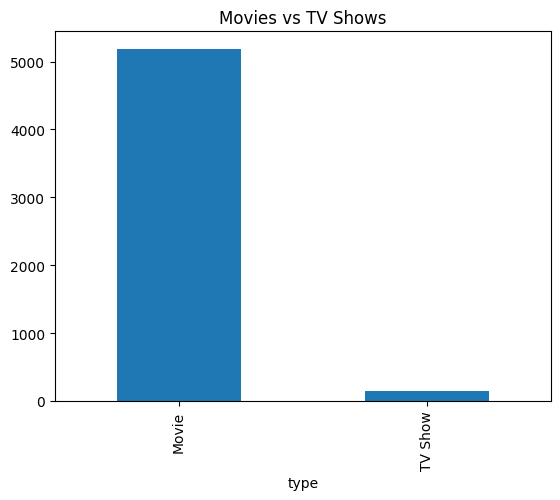

In [ ]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

6. Content Distribution by Country

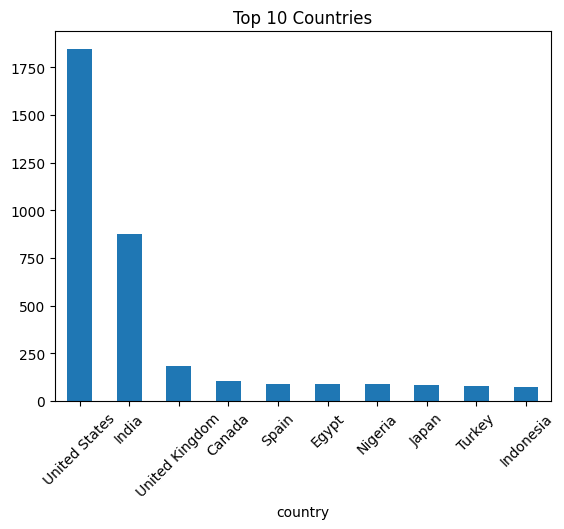

In [ ]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xticks(rotation=45)
plt.show()

7. Release Year Analysis

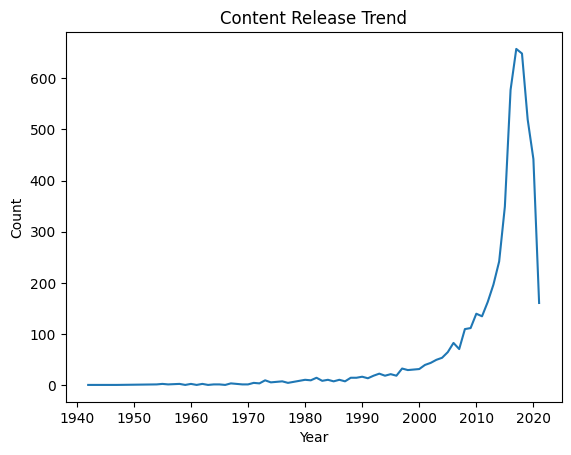

In [ ]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

8. Ratings Distribution

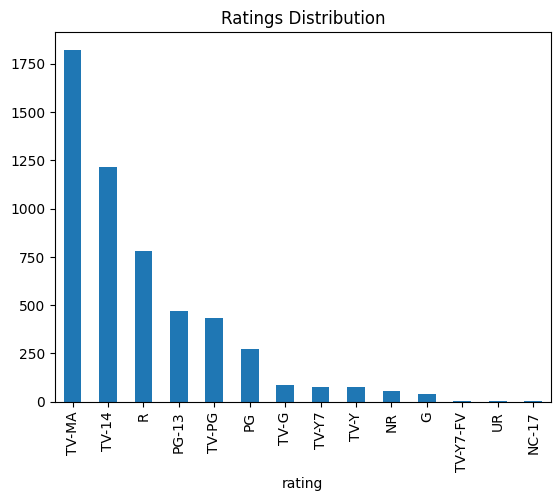

In [ ]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

9. Duration Analysis

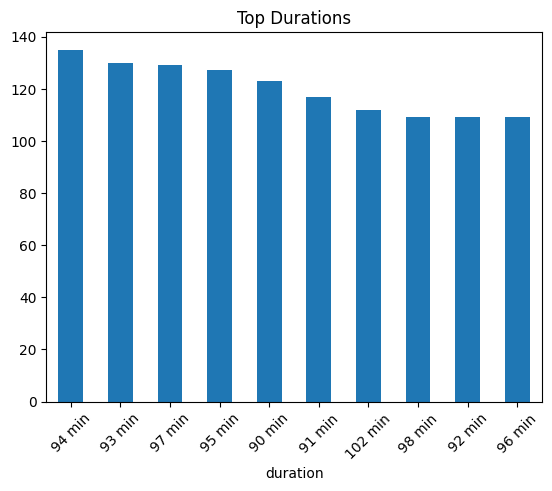

In [ ]:
df['duration'].value_counts().head(10).plot(kind='bar')
plt.title("Top Durations")
plt.xticks(rotation=45)
plt.show()

10. Heatmap (Advanced EDA 🔥)

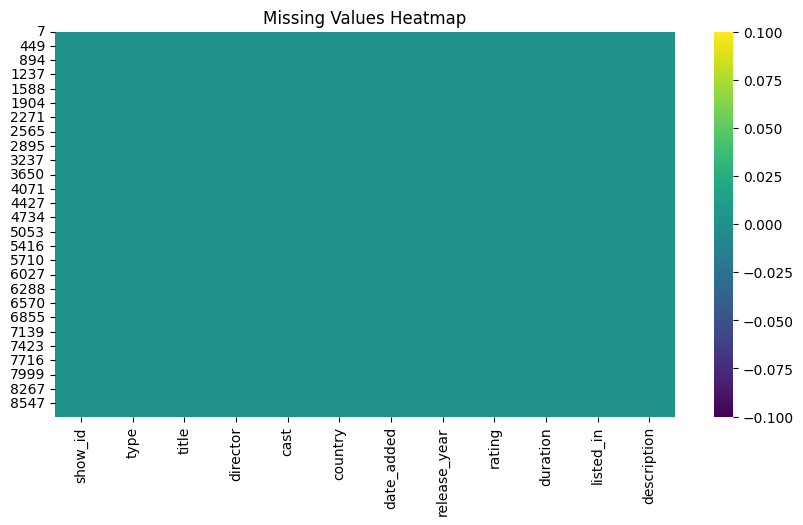

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


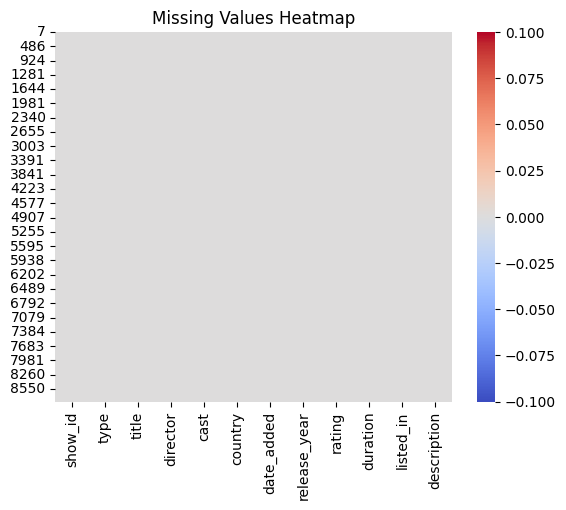

In [ ]:
sns.heatmap(df.isnull(), cbar=True, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

_______________________________________________________________________________

Linear Programming Problem (Netflix Content Optimization)

1: Idea

👉 Assume (On basis of EDA):

Movies engagement ≈ 8
Series engagement ≈ 10

👉 Cost:

Movie = 4
Series = 6

👉 Budget = 180

2: Install + Import

In [ ]:
!pip install pulp
from pulp import *

3: Model Create

In [ ]:
model = LpProblem("Netflix_Optimization", LpMaximize)

4: Decision Variables

In [ ]:
movies = LpVariable('Movies', lowBound=0)
series = LpVariable('Series', lowBound=0)

5: Objective Function

In [ ]:
model += 8*movies + 10*series

6: Constraints

In [ ]:
# Budget constraint
model += 4*movies + 6*series <= 180

# Production limits
model += movies <= 40
model += series <= 30

7: Solve Model

In [ ]:
model.solve()

1

8: Output

In [ ]:
print("Movies to produce:", movies.varValue)
print("Series to produce:", series.varValue)
print("Maximum Engagement:", value(model.objective))

Movies to produce: 40.0
Series to produce: 3.3333333
Maximum Engagement: 353.333333


________________________________________________________________________________

Linear Regression (Machine Learning Part)

1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

2. Create Feature & Target

In [ ]:
# Count content per year
year_data = df['release_year'].value_counts().sort_index()

# Convert to DataFrame
year_df = pd.DataFrame({
    'year': year_data.index,
    'count': year_data.values
})

year_df.head()

,year,count
0,1942,1
1,1944,1
2,1945,1
3,1946,1
4,1947,1


3. Define X and y

In [ ]:
X = year_df[['year']]   # independent variable
y = year_df['count']    # dependent variable

4. Train Model

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

5. Prediction

In [ ]:
future_years = np.array([[2023], [2024], [2025]])
predictions = model.predict(future_years)

for year, pred in zip(future_years, predictions):
    print(f"Year {year[0]} → Predicted Content: {int(pred)}")

Year 2023 → Predicted Content: 240
Year 2024 → Predicted Content: 244
Year 2025 → Predicted Content: 248


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


6. Visualization

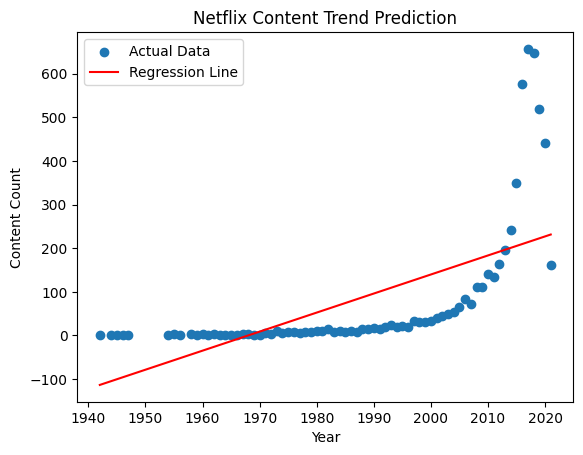

In [ ]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), color='red', label="Regression Line")

plt.xlabel("Year")
plt.ylabel("Content Count")
plt.title("Netflix Content Trend Prediction")
plt.legend()

plt.show()

________________________________________________________________________________

Advanced Model (Polynomial Regression)

1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

2. Prepare Data

In [ ]:
# Count content per year
year_data = df['release_year'].value_counts().sort_index()

year_df = pd.DataFrame({
    'year': year_data.index,
    'count': year_data.values
})

X = year_df[['year']]
y = year_df['count']

3. Apply Polynomial Features

In [ ]:
poly = PolynomialFeatures(degree=3)   # degree 3 = complex curve
X_poly = poly.fit_transform(X)

4. Train Model

In [ ]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

5. Prediction

In [ ]:
future_years = np.array([[2023], [2024], [2025]])
future_poly = poly.transform(future_years)

predictions = model.predict(future_poly)

for year, pred in zip(future_years, predictions):
    print(f"Year {year[0]} → Predicted Content: {int(pred)}")

Year 2023 → Predicted Content: 570
Year 2024 → Predicted Content: 609
Year 2025 → Predicted Content: 649


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


6. Visualization

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


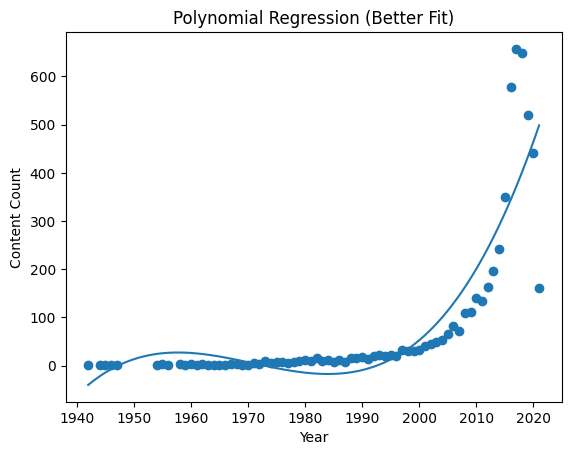

In [ ]:
plt.scatter(X, y)

# Smooth curve
X_range = np.linspace(X.min(), X.max(), 100)
X_range_poly = poly.transform(X_range)

plt.plot(X_range, model.predict(X_range_poly))

plt.xlabel("Year")
plt.ylabel("Content Count")
plt.title("Polynomial Regression (Better Fit)")

plt.show()

___________________________________________________________________________

Most liked / Popular Content

In [ ]:
# Most frequent titles (approx popularity)
df['title'].value_counts().head(10)

,count
title,
Zubaan,1
Sankofa,1
The Great British Baking Show,1
The Starling,1
Yoga Hosers,1
Yo-Kai Watch: The Movie,1
Yes or No 2.5,1
Yes or No 2,1
Yes or No,1


In [ ]:
df['type'].value_counts()

,count
type,
Movie,5185
TV Show,147


In [ ]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,1822
TV-14,1214
R,778
PG-13,470
TV-PG,431
PG,275
TV-G,84
TV-Y7,76
TV-Y,76


Data after 2007 (Netflix launch streaming)

In [ ]:
df_2007 = df[df['release_year'] >= 2007]
df_2007.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
27,s28,Movie,Grown Ups,Dennis Dugan,"Adam Sandler, Kevin James, Chris Rock, David S...",United States,"September 20, 2021",2010,PG-13,103 min,Comedies,Mourning the loss of their beloved junior high...
28,s29,Movie,Dark Skies,Scott Stewart,"Keri Russell, Josh Hamilton, J.K. Simmons, Dak...",United States,"September 19, 2021",2013,PG-13,97 min,"Horror Movies, Sci-Fi & Fantasy",A family’s idyllic suburban life shatters when...


In [ ]:
df_2007.shape

(4523, 12)

CONTENT GROWTH AFTER 2007

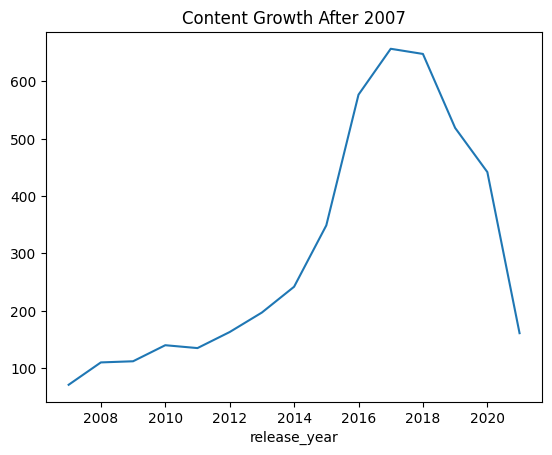

In [ ]:
df_2007['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth After 2007")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_2007['rating_encoded'] = le.fit_transform(df_2007['rating'])

/tmp/ipykernel_10051/3600720165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2007['rating_encoded'] = le.fit_transform(df_2007['rating'])


CORRELATION OF RELEASING YEAR AND RATING ENCODED

In [ ]:
correlation = df_2007[['release_year', 'rating_encoded']].corr()
print(correlation)

                release_year  rating_encoded
release_year        1.000000        0.250295
rating_encoded      0.250295        1.000000


CORRELATION HEATMAP

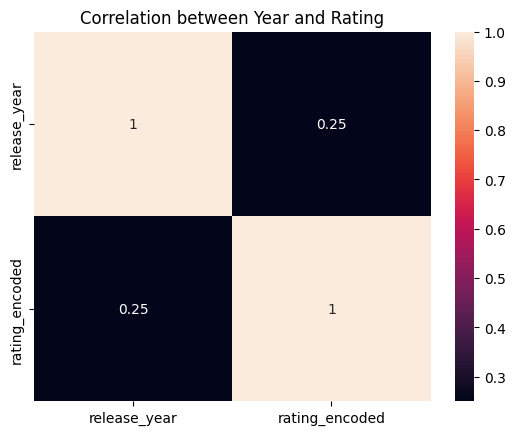

In [ ]:
import seaborn as sns

sns.heatmap(correlation, annot=True)
plt.title("Correlation between Year and Rating")
plt.show()

PIVOT TABLE OF YEAR VS CONTENT TYPE

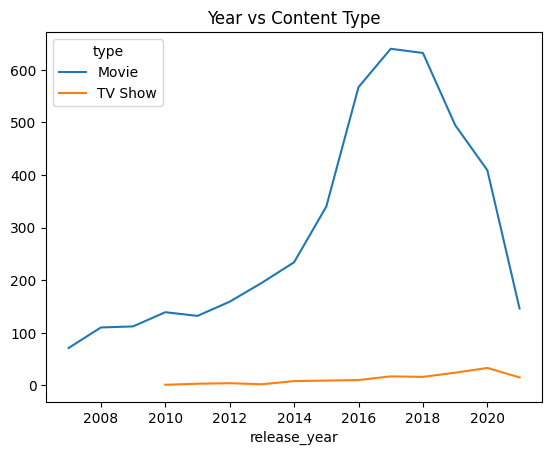

In [ ]:
pivot = pd.pivot_table(
    df_2007,
    values='show_id',
    index='release_year',
    columns='type',
    aggfunc='count'
)

pivot.plot()
plt.title("Year vs Content Type")
plt.show()

CONTENT RATING DISTRIBUTION OVER YEARS

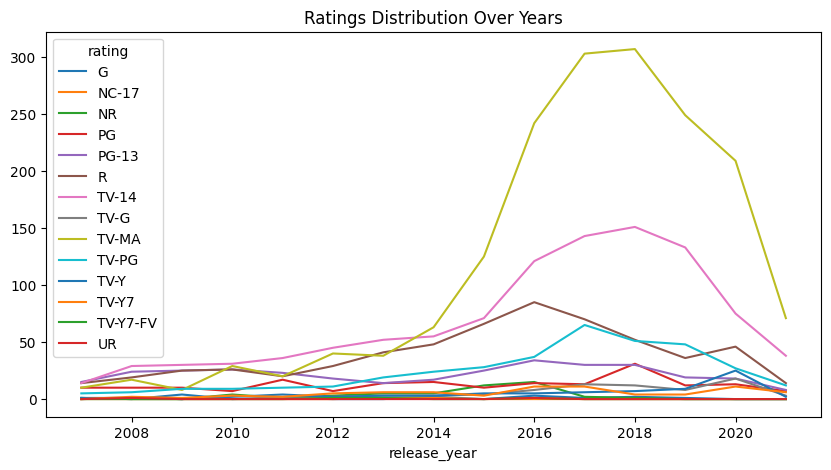

In [ ]:
rating_year = pd.crosstab(df_2007['release_year'], df_2007['rating'])

rating_year.plot(figsize=(10,5))
plt.title("Ratings Distribution Over Years")
plt.show()

RATINGS DISTRIBUTION AFTER 2007

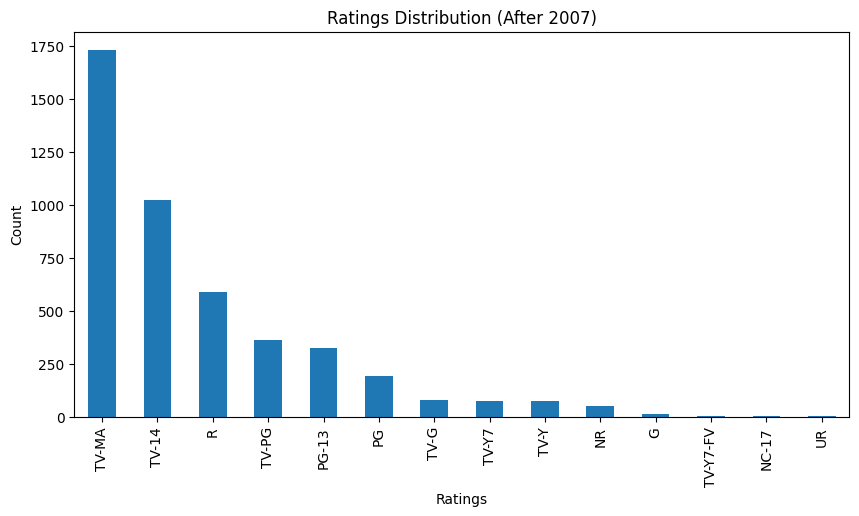

In [ ]:
plt.figure(figsize=(10,5))

df_2007['rating'].value_counts().plot(kind='bar')

plt.title("Ratings Distribution (After 2007)")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

HISTOGRAM RATINGS

/tmp/ipykernel_10051/3106517809.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2007['rating_encoded'] = le.fit_transform(df_2007['rating'])


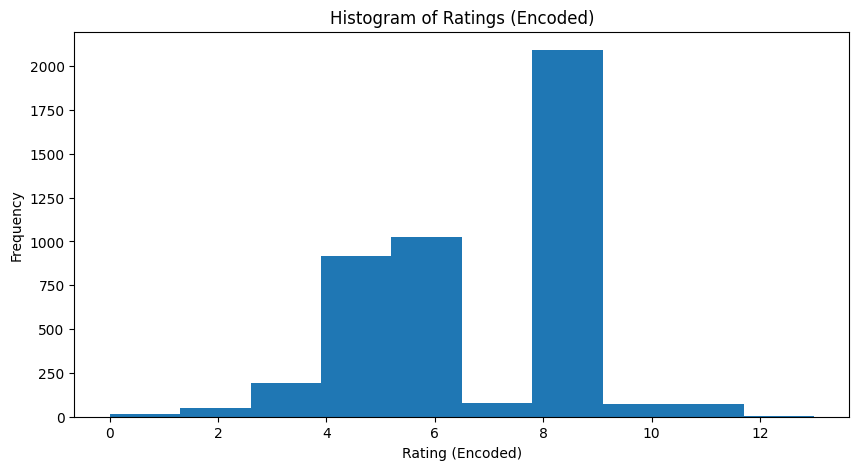

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_2007['rating_encoded'] = le.fit_transform(df_2007['rating'])

plt.figure(figsize=(10,5))

plt.hist(df_2007['rating_encoded'], bins=10)

plt.title("Histogram of Ratings (Encoded)")
plt.xlabel("Rating (Encoded)")
plt.ylabel("Frequency")

plt.show()

HISTOGRAM OF RATINGS OVER YEARS

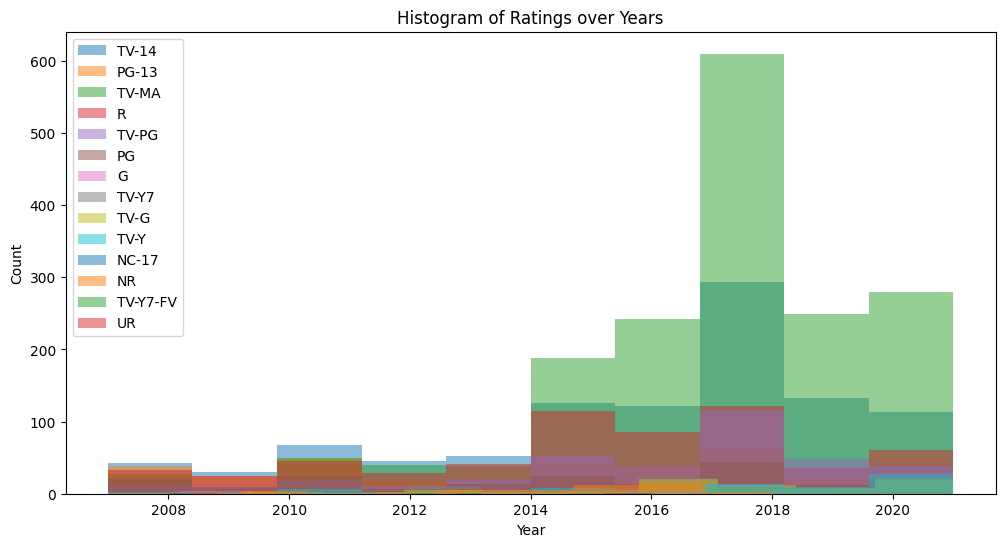

In [ ]:
plt.figure(figsize=(12,6))

for rating in df_2007['rating'].unique():
    subset = df_2007[df_2007['rating'] == rating]
    plt.hist(subset['release_year'], bins=10, alpha=0.5, label=rating)

plt.legend()
plt.title("Histogram of Ratings over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

TOP CONTENT TRAFFIC COUNTRIES

In [ ]:
top_countries = df_2007['country'].value_counts().head(5)
print(top_countries)

country
United States     1501
India              705
United Kingdom     164
Canada             103
Spain               91
Name: count, dtype: int64


TOP INDEXED COUNTRIES

In [ ]:
top5 = top_countries.index

df_top = df_2007[df_2007['country'].isin(top5)]

country_content = pd.crosstab(df_top['country'], df_top['type'])
print(country_content)

type            Movie  TV Show
country                       
Canada            100        3
India             698        7
Spain              84        7
United Kingdom    147       17
United States    1475       26


CONTENT TYPE POPULARITIES IN TOP 5 COUNTRIES

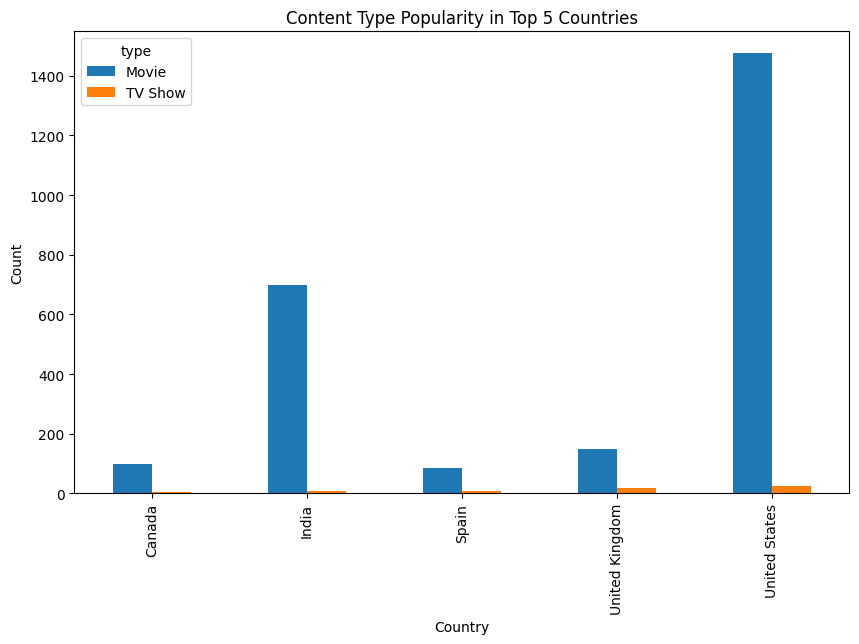

In [ ]:
country_content.plot(kind='bar', figsize=(10,6))

plt.title("Content Type Popularity in Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

Trend of Movies vs TV Shows Over Years

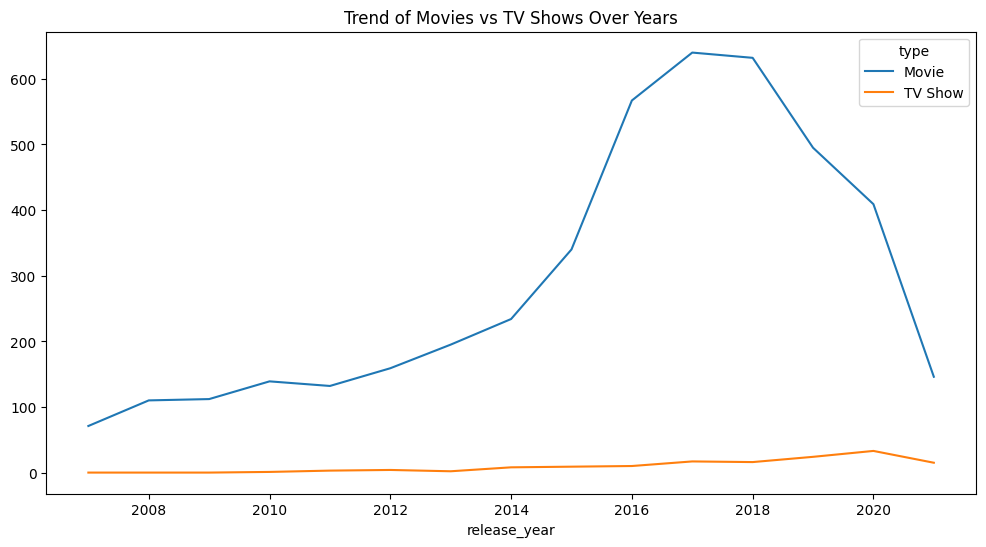

In [ ]:
year_type = pd.crosstab(df_2007['release_year'], df_2007['type'])

year_type.plot(figsize=(12,6))

plt.title("Trend of Movies vs TV Shows Over Years")
plt.show()

Type and Rating between Movies and TV Shows

In [ ]:
best_content = df_2007.groupby(['type', 'rating']).size().sort_values(ascending=False).head(10)
print(best_content)

type     rating
Movie    TV-MA     1650
         TV-14      989
         R          591
         TV-PG      348
         PG-13      326
         PG         190
TV Show  TV-MA       81
Movie    TV-G        77
         TV-Y        70
         TV-Y7       69
dtype: int64


Rating Counts

In [ ]:
df_2007['type'].value_counts()
df_2007['rating'].value_counts().head(5)

,count
rating,
TV-MA,1731
TV-14,1024
R,591
TV-PG,361
PG-13,326


Movie vs TV Show count

In [ ]:
df_india['type'].value_counts()

,count
type,
Movie,755
TV Show,8


Content type in India

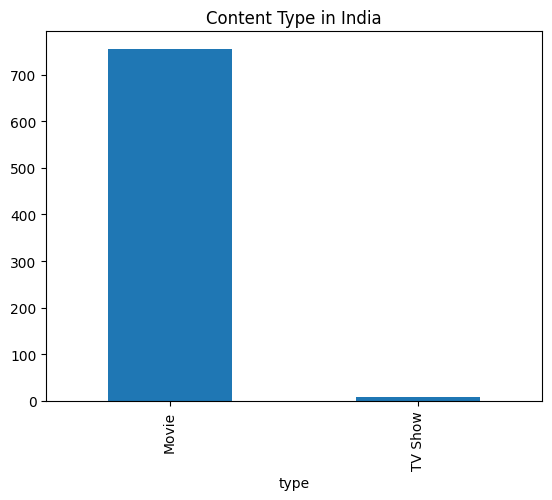

In [ ]:
df_india['type'].value_counts().plot(kind='bar')
plt.title("Content Type in India")
plt.show()

Rating Count of India

In [ ]:
df_india['rating'].value_counts().head(10)

,count
rating,
TV-14,416
TV-MA,217
TV-PG,89
PG-13,11
TV-Y7,11
PG,6
NR,6
R,4
TV-G,2


India Content of Netflix growth over Years

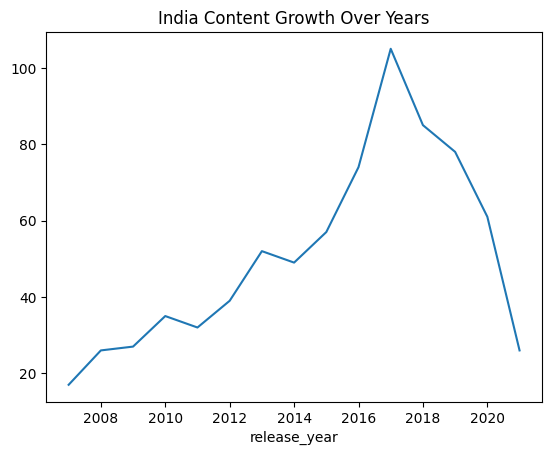

In [ ]:
india_year = df_india['release_year'].value_counts().sort_index()

india_year.plot()
plt.title("India Content Growth Over Years")
plt.show()

Prediction Model

In [ ]:
df_model = df_2007.copy()

# Example scoring
rating_score = {
    'TV-MA': 5,
    'TV-14': 4,
    'PG-13': 3,
    'PG': 2,
    'G': 1
}

df_model['rating_score'] = df_model['rating'].map(rating_score)

# Final engagement score
df_model['engagement'] = df_model['rating_score'] + (df_model['release_year'] - 2000)/10

In [ ]:
# Example scoring
rating_score = {
    'TV-MA': 5,
    'TV-14': 4,
    'PG-13': 3,
    'PG': 2,
    'G': 1
}

df_model['rating_score'] = df_model['rating'].map(rating_score)

# Final engagement score
df_model['engagement'] = df_model['rating_score'] + (df_model['release_year'] - 2000)/10

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_type = LabelEncoder()

df_model['country_enc'] = le_country.fit_transform(df_model['country'])
df_model['type_enc'] = le_type.fit_transform(df_model['type'])

In [ ]:
X = df_model[['country_enc', 'type_enc', 'release_year']]
y = df_model['engagement']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

# Identify rows where y is NaN
nan_mask = y.isna()

# Filter X and y to remove rows with NaN in y
X_clean = X[~nan_mask]
y_clean = y[~nan_mask]

model.fit(X_clean, y_clean)

RandomForestRegressor()

In [ ]:
# Encode input (example: India + Movie)
country = le_country.transform(['India'])[0]
content = le_type.transform(['Movie'])[0]

# IMPORTANT: DataFrame format use karna hai
import pandas as pd

input_data = pd.DataFrame({
    'country_enc': [country],
    'type_enc': [content],
    'release_year': [2025]
})

# Prediction
pred = model.predict(input_data)

print("Predicted Engagement:", pred[0])

Predicted Engagement: 6.573096298095242


In [ ]:
countries = ['India', 'United States', 'United Kingdom']

for c in countries:
    c_enc = le_country.transform([c])[0]
    m = le_type.transform(['Movie'])[0]
    s = le_type.transform(['TV Show'])[0]

    input_movie = pd.DataFrame({
        'country_enc': [c_enc],
        'type_enc': [m],
        'release_year': [2025]
    })

    input_series = pd.DataFrame({
        'country_enc': [c_enc],
        'type_enc': [s],
        'release_year': [2025]
    })

    print(f"\nCountry: {c}")
    print("Movie:", model.predict(input_movie)[0])
    print("Series:", model.predict(input_series)[0])


Country: India
Movie: 6.573096298095242
Series: 7.087360576923089

Country: United States
Movie: 5.890990923166636
Series: 6.61937133795571

Country: United Kingdom
Movie: 6.110773809523817
Series: 6.607916666666675


In [ ]:
# Encode
c = le_country.transform(['India'])[0]
m = le_type.transform(['Movie'])[0]
s = le_type.transform(['TV Show'])[0]

# DataFrames
movie_input = pd.DataFrame({
    'country_enc': [c],
    'type_enc': [m],
    'release_year': [2025]
})

series_input = pd.DataFrame({
    'country_enc': [c],
    'type_enc': [s],
    'release_year': [2025]
})

# Predictions
movie_eng = model.predict(movie_input)[0]
series_eng = model.predict(series_input)[0]

print("Movie Engagement:", movie_eng)
print("Series Engagement:", series_eng)

Movie Engagement: 6.573096298095242
Series Engagement: 7.087360576923089


In [ ]:
!pip install pulp
from pulp import *

In [ ]:
lpp_model = LpProblem("Netflix_Optimization", LpMaximize)

In [ ]:
movies = LpVariable('Movies', lowBound=0)
series = LpVariable('Series', lowBound=0)

In [ ]:
lpp_model += movie_eng * movies + series_eng * series

In [ ]:
# Budget
lpp_model += 4*movies + 6*series <= 200

# Limits
lpp_model += movies <= 50
lpp_model += series <= 40

In [ ]:
lpp_model.solve()

1

In [ ]:
print("Optimal Movies:", movies.varValue)
print("Optimal Series:", series.varValue)
print("Maximum Engagement:", value(lpp_model.objective))

Optimal Movies: 50.0
Optimal Series: 0.0
Maximum Engagement: 328.65481490476213


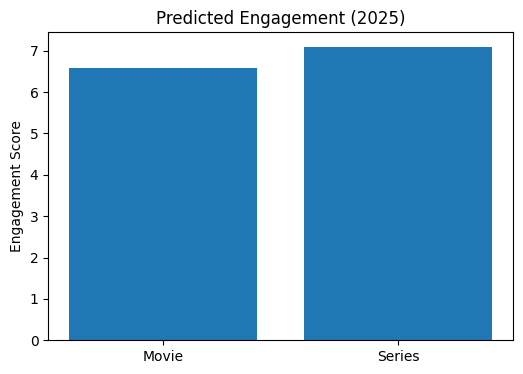

In [ ]:
labels = ['Movie', 'Series']
values = [movie_eng, series_eng]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Predicted Engagement (2025)")
plt.ylabel("Engagement Score")

plt.show()

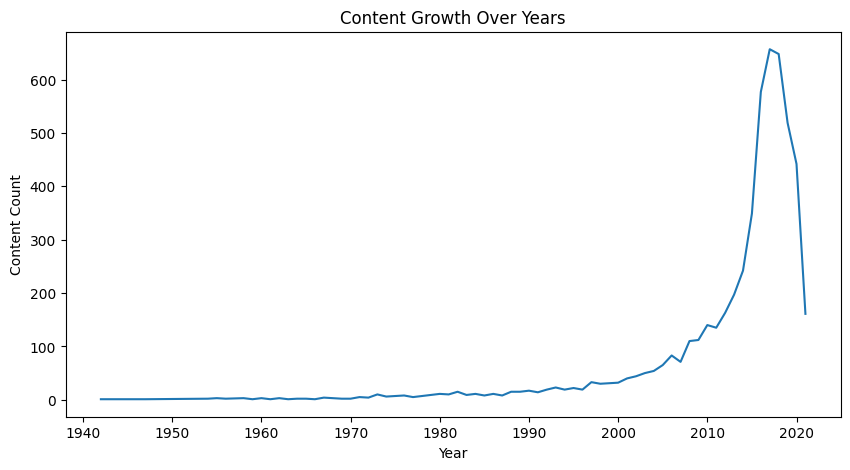

In [ ]:
year_data = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_data.index, year_data.values)

plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Content Count")

plt.show()

Optimal content Production LPP

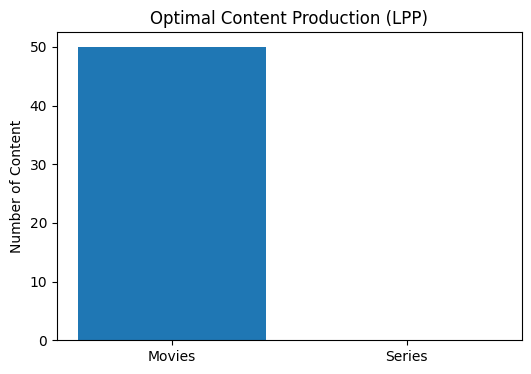

In [ ]:
labels = ['Movies', 'Series']
values = [movies.varValue, series.varValue]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Optimal Content Production (LPP)")
plt.ylabel("Number of Content")

plt.show()

2026 Movie vs Series Prediction

In [ ]:
# Encode India example (tu country change bhi kar sakta hai)
c = le_country.transform(['India'])[0]
m = le_type.transform(['Movie'])[0]
s = le_type.transform(['TV Show'])[0]

# 2026 inputs
movie_input_2026 = pd.DataFrame({
    'country_enc': [c],
    'type_enc': [m],
    'release_year': [2026]
})

series_input_2026 = pd.DataFrame({
    'country_enc': [c],
    'type_enc': [s],
    'release_year': [2026]
})

# Predictions
movie_2026 = model.predict(movie_input_2026)[0]
series_2026 = model.predict(series_input_2026)[0]

print("2026 Movie Engagement:", movie_2026)
print("2026 Series Engagement:", series_2026)

2026 Movie Engagement: 6.573096298095242
2026 Series Engagement: 7.087360576923089


2025 vs 2026 Engagement Prediction

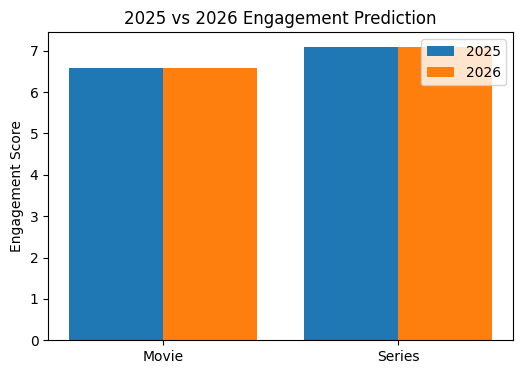

In [ ]:
labels = ['Movie', 'Series']

values_2025 = [movie_eng, series_eng]
values_2026 = [movie_2026, series_2026]

x = range(len(labels))

plt.figure(figsize=(6,4))

plt.bar(x, values_2025, width=0.4, label='2025')
plt.bar([i + 0.4 for i in x], values_2026, width=0.4, label='2026')

plt.xticks([i + 0.2 for i in x], labels)

plt.title("2025 vs 2026 Engagement Prediction")
plt.ylabel("Engagement Score")
plt.legend()

plt.show()

In [ ]:
# Encode India
c = le_country.transform(['India'])[0]
m = le_type.transform(['Movie'])[0]
s = le_type.transform(['TV Show'])[0]

# Inputs for 2027
movie_input = pd.DataFrame({
    'country_enc': [c],
    'type_enc': [m],
    'release_year': [2027]
})

series_input = pd.DataFrame({
    'country_enc': [c],
    'type_enc': [s],
    'release_year': [2027]
})

# Predictions
movie_2027 = model.predict(movie_input)[0]
series_2027 = model.predict(series_input)[0]

print("Movie 2027:", movie_2027)
print("Series 2027:", series_2027)

Movie 2027: 6.573096298095242
Series 2027: 7.087360576923089


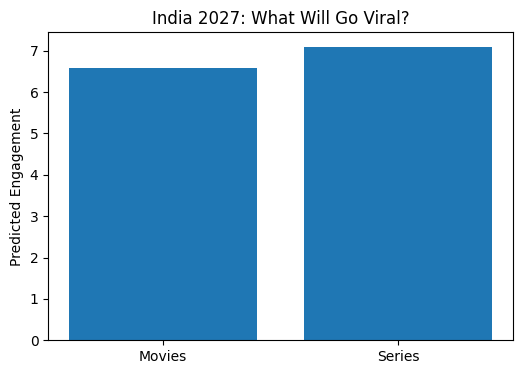

In [ ]:
labels = ['Movies', 'Series']
values = [movie_2027, series_2027]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("India 2027: What Will Go Viral?")
plt.ylabel("Predicted Engagement")

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_rating = LabelEncoder()
df_model['rating_enc'] = le_rating.fit_transform(df_model['rating'])

In [ ]:
X = df_model[['country_enc', 'type_enc', 'release_year', 'rating_enc']]
y = df_model['engagement']

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

# Identify rows where y is NaN
nan_mask = y.isna()

# Filter X and y to remove rows with NaN in y
X_clean = X[~nan_mask]
y_clean = y[~nan_mask]

model.fit(X_clean, y_clean)

RandomForestRegressor()

In [ ]:
c = le_country.transform(['India'])[0]
m = le_type.transform(['Movie'])[0]   # ya TV Show bhi try kar sakta hai

ratings = df_model['rating'].unique()

results = []

for r in ratings:
    r_enc = le_rating.transform([r])[0]

    input_data = pd.DataFrame({
        'country_enc': [c],
        'type_enc': [m],
        'release_year': [2027],
        'rating_enc': [r_enc]
    })

    pred = model.predict(input_data)[0]
    results.append((r, pred))

In [ ]:
# Sort by engagement
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

# Top 5
top5 = results_sorted[:5]

for r, val in top5:
    print(r, "→", val)

TV-MA → 7.100000000000012
TV-PG → 7.100000000000012
TV-Y7 → 7.100000000000012
TV-Y → 7.100000000000012
TV-Y7-FV → 7.100000000000012


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Assume df_model ready hai
X = df_model[['country_enc', 'type_enc', 'release_year']]
y = df_model['engagement']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

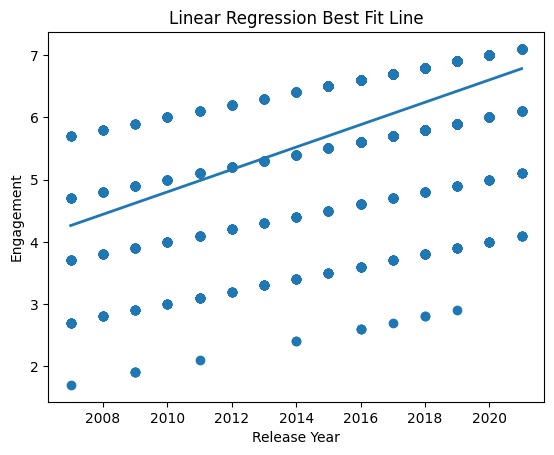

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Single feature for visualization
X_single = df_model[['release_year']]
y = df_model['engagement']

# Handle NaN values in y before training
nan_mask = y.isna()
X_single_clean = X_single[~nan_mask]
y_clean = y[~nan_mask]

# Train
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_single_clean, y_clean)

# Predictions
y_pred = lr.predict(X_single_clean)

# Sort for line
sorted_idx = np.argsort(X_single_clean.values.flatten())

# Plot
plt.scatter(X_single_clean, y_clean)
plt.plot(X_single_clean.values.flatten()[sorted_idx],
         y_pred[sorted_idx],
         linewidth=2)

plt.xlabel("Release Year")
plt.ylabel("Engagement")
plt.title("Linear Regression Best Fit Line")

plt.show()